## Micro Domain

The micro domain is defined by a bounding box and a smooth function parameterising the floor of the micro domain. 

In [19]:
import numpy as np
import torch as pt
import torch.autograd as agrad
import matplotlib.pyplot as plt
from util.plot_tools import *
from architecture.fno_cnn_1d import *
from boundary_solvers.blobs import *
from boundary_solvers.geometry import *
from scipy.sparse.linalg import LinearOperator #, gmres
from operators.stokes_operator import StokesAdjointBoundaryOp
import torch.nn as nn
import time
from boundary_solvers.geometry_torch import *
from architecture.session import egeofno_ver2, svdfno_ver2, svdfno_ver1, svdfno_ver3, fno_ver2


net_dir = "/mnt/data0/emastr/article_training_hugedata/"
MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
simulation_dir = "/home/emastr/deep-micro-slip-model/data/stokes_fenics/"
data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_big_clean.torch"

## Create data loader

Load and transform the data. 

In [20]:
device = "cpu" # "cuda:0"
# Standard features (coordinates, derivatives of parameterisation)

num_pts = 256
full_data = torch.load(data_dir)
M = 200

data_in_dict = {full_data['info']['in_ch'][i]: full_data['X'][:M, i] for i in range(len(full_data['info']['in_ch']))}
data_out_dict = {full_data['info']['out_ch'][i]: full_data['Y'][:M, i] for i in range(len(full_data['info']['out_ch']))}

X_gmres = torch.concatenate((data_in_dict['inter_precomp_r'][:M, None], data_in_dict['inter_precomp_i'][:M, None]), dim=1)
Y_gmres = torch.concatenate((data_out_dict['precomp_r'][:M, None], data_out_dict['precomp_i'][:M, None]), dim=1)
# Reduced features (trust fourier transform to handle the rest)
#features = {'x', 'y', 'vx', 'vy'}


#Y_gmres = Y_gmres[:, :, ::s]
#X_gmres = X_gmres[:, :, ::s]
print(X_gmres.shape)
print(list(data_in_dict.keys()))
print(list(data_out_dict.keys()))


torch.Size([200, 2, 256])
['zr', 'zi', 'dzr', 'dzi', 'ddzr', 'ddzi', 'inter_precomp_r', 'inter_precomp_i', 'inter_precomp_der_r', 'inter_precomp_der_i', 'w', 't']
['precomp_r', 'precomp_i', 'precomp_der_r', 'precomp_der_i']


Create network

In [21]:
net = fno_ver2(device=device)
#net_data = torch.load(f"{net_dir}fno_ver2_seed0_40000.Torch", map_location=torch.device(device))
net_data = torch.load(f"{net_dir}fno_vanilla_ver2_seed0_40000.Torch", map_location=torch.device(device))
net.load_state_dict(net_data["state dict"])

net_settings =  {"num_pts": num_pts, "input_features": net_data["settings"]["input_features"], "device": device, "dtype": torch.float}
net_data_set = GeomData(data_dir, net_data["settings"]["input_features"], net_data["settings"]["output_features"], random_roll=False, device=device, dtype=torch.float32)
X_net = net_data_set.X[:M].to(torch.float32)
Y_net = net_data_set.Y[:M].to(torch.float32)

print(net_data["settings"]["output_features"])

['rx', 'ry', 'drx', 'dry']


Do training

Compare to GMRES

In [22]:
from util import gmres

# Create a forward operator
def op_factory(inp):
    Z   = inp['zr']   + 1j * inp['zi']
    dZ  = inp['dzr']  + 1j * inp['dzi']
    ddZ = inp['ddzr'] + 1j * inp['ddzi']
    W = inp['w']
    a = torch.ones(Z.shape[0],) * 0.5 * 1j
    return StokesAdjointBoundaryOp(Z, dZ, ddZ, W, a)

op_test = op_factory(data_in_dict)

In [23]:
from util.gmres import gmres
from torch import tensordot as dot
from torch.linalg import vector_norm as norm

class gmresNet(nn.Module):
    def __init__(self, steps, callback=None, verbose=False):
        super().__init__()
        self.steps = steps
        self.callback = callback
        self.verbose = verbose
        
        
    def forward(self, x, ops):
        y = torch.zeros_like(x)
        for n in range(x.shape[0]):
            y[n, :] = gmres(lambda x: ops(x, n), x[None, n, :], 
                            steps=self.steps, 
                            callback=self.callback, 
                            verbose=self.verbose)
        return y


In [24]:
# print(V_test.shape)
#ops = [lambda x: torch.cat([op_test(x[r].view(1, C, M), idx=[n]).view(1, C*M) 
                            #for r in range(x.shape[0])], dim=0) for n in range(N)]
# x is shape (C, M) -> 
ops =[]
K = op_test.K
(N, C, M) = X_gmres.shape
op = lambda x, n, s: 1.*x + dot(x.view(x.shape[0], C, M//s), K[n, :, :, ::s, ::s]*s, [[1,2],[1,3]]).view(x.shape[0], C*(M//s))

X_gmres_view = X_gmres.view(N, C*M)
X_gmres_view = X_gmres_view.to(torch.float64)

            
#n2 = 10
#print(f"{norm(ops[n](Y_test[None, 11].view(1, C*M)).view(1, C, M) - V_test[None, 11])},{n}")
#callback = lambda *args: print(f"{norm(opnx(Y_test[None, n2].view(1, C*M),n2).view(1, C, M) - V_test[None, n2]):.2e}")
resnet = gmresNet(steps=12)
op_sample = lambda X, s: resnet(X[:,:,::s].view(N, C*(M//s)).to(torch.float64), \
                                lambda x, n: op(x, n, s)).view(N, C, M//s)

Y_gmres = op_sample(X_gmres, 1)

In [25]:
t_net = time.time()
Y_net_apx = net(X_net).detach()
t_net = time.time() - t_net

We find corrupt data points by checking for outliers in the training error.

In [26]:
iters = list(range(2, 43, 3))
times = []
error = []
stride = [2, 4, 8]
for s in stride:
    print(s)
    Y_gmres_true = op_sample(X_gmres, 1)
    t = time.time()
    Y_gmres_apx = op_sample(X_gmres, s)
    times.append(time.time() - t)
    #error.append(np.array([norm(Y_gmres[n,:,::s] - Y_gmres_apx[n])/norm(Y_gmres[n,:,::s]) for n in range(N)]))
    error.append(np.array([norm(Y_gmres_true[n,:,::s] - Y_gmres_apx[n])/norm(Y_gmres_true[n,:,::s]) for n in range(N)]))
    
    
error3 = np.array([(norm(Y_net[n] - Y_net_apx[n])/norm(Y_net[n])).cpu() for n in range(N)])
error32 = error3#np.array([(norm(Y_net2[n] - Y_net2_apx[n])/norm(Y_net2[n])).cpu() for n in range(N)])

error_mean = [np.mean(e) for e in error]
error3_mean = np.mean(error3)

2
4
8


Below, we compare a naive implementation of GMRES (no FMM involved), to FNO.

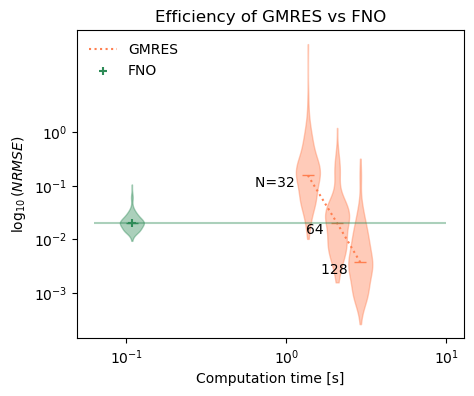

In [27]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Sample name')


def violinplot(ax, data, positions, *args, **kwargs):
    color = kwargs.pop("color", "blue")
    labels = kwargs.pop("labels", None)
    mainlabel = kwargs.pop("mainlabel", None)
    connected = kwargs.pop("connected", False)
    parts = ax.violinplot(data, *args, positions=positions, **kwargs)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.4)
    pc = parts["cmedians"]
    pc.set_linewidth(1)
    pc.set_color(color)
    pc.set_linestyle("-")    
    if labels is not None:
        for label, pos, dat in zip(labels, positions, data):
            plt.text(pos, np.median(dat), label, horizontalalignment='right', verticalalignment='top')
    quartile1, medians, quartile3 = np.percentile(data, [25, 50, 75], axis=1)
    if connected:
        ax.plot(positions, medians, color=color, linestyle=':', label=mainlabel)
    else:
        ax.scatter(positions, medians, color=color, marker="+", label=mainlabel)
    
    #ax.scatter(positions, medians, marker='o', color='white', s=30, zorder=3)
    #ax.vlines(positions, quartile1, quartile3, color='k', linestyle='-', lw=5)
    return 0


def log_labels(start, end):
    return np.arange(start, end+1), [f"$10^{{{i}}}$" for i in range(start, end+1)]


log_net_error = np.log10(error3)
log_net_error_median = np.median(log_net_error)
log_error = [np.log10(e) for e in error]
log_error_medians = [np.median(e) for e in log_error]
log_times = np.log10(times)
log_net_time = np.log10(t_net)

labels = [f"{256//s}   " for s in stride]
labels[-1] = "N=" + labels[-1]


plt.figure(figsize=(5,4))

colors = ["coral", "seagreen", "steelblue", "indianred"]
# GMRES
violinplot(plt.gca(), log_error, log_times, widths=0.15, showmedians=True, showextrema=False, color=colors[0], labels=labels, connected=True, mainlabel="GMRES")
# FNO
plt.gca().hlines(log_net_error_median, -1.2, 1, color=colors[1], linestyle='-', alpha=0.4)
violinplot(plt.gca(), [log_net_error], [log_net_time], widths=0.15, showmedians=True, showextrema=False, color=colors[1], mainlabel="FNO")

# Labels
plt.xlabel(f"Computation time [s]")
plt.ylabel("$\\log_{10}(NRMSE)$")
plt.title("Efficiency of GMRES vs FNO")
plt.yticks(*log_labels(-3,0))
plt.xticks(*log_labels(-1,1))
plt.legend(loc="upper left", frameon=False)


plt.gcf().savefig(f"{figures_dir}gmres_vs_fno.pdf")